In [11]:
import tellurium as te
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import platform
import roadrunner
import math
import multiprocessing as mp
from multiprocessing import Pool, cpu_count, Manager
from functools import partial
import psutil
from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings
from scipy.signal import find_peaks, hilbert, savgol_filter
from scipy.interpolate import interp1d
warnings.filterwarnings('ignore')

# Silence RoadRunner log messages completely
roadrunner.Logger.setLevel(roadrunner.Logger.LOG_CRITICAL)

print("🧪 ChicoOscillation: Simplified Yeast Dynamics Analysis")
print("📊 Focus: Short-term dynamics with coarse-grained encoding")
print("="*60)

🧪 ChicoOscillation: Simplified Yeast Dynamics Analysis
📊 Focus: Short-term dynamics with coarse-grained encoding


In [12]:
# === CPU OPTIMIZATION DETECTION ===
def detect_cpu_config():
    """Detect optimal CPU configuration for Radeon/AMD processors"""
    cpu_count_total = cpu_count()
    cpu_info = platform.processor()
    
    # Check if this is an AMD/Radeon CPU
    is_amd = any(keyword in cpu_info.lower() for keyword in ['amd', 'radeon', 'ryzen', 'epyc', 'athlon'])
    
    if is_amd:
        # AMD CPUs often benefit from using physical cores only
        try:
            physical_cores = psutil.cpu_count(logical=False)
            logical_cores = psutil.cpu_count(logical=True)
            
            # For AMD, often best to use 75-85% of physical cores for compute-heavy tasks
            optimal_workers = max(1, int(physical_cores * 0.8)) if physical_cores else max(1, int(cpu_count_total * 0.7))
            
            print(f"🔧 AMD/Radeon CPU detected: {cpu_info}")
            print(f"   Physical cores: {physical_cores}, Logical cores: {logical_cores}")
            print(f"   Optimal workers for simulation: {optimal_workers}")
            
            return optimal_workers, True
        except:
            # Fallback if psutil fails
            optimal_workers = max(1, int(cpu_count_total * 0.7))
            print(f"🔧 AMD CPU detected (fallback): using {optimal_workers} workers")
            return optimal_workers, True
    else:
        # Non-AMD CPU: use standard approach
        optimal_workers = max(1, cpu_count_total - 1)
        print(f"🔧 Non-AMD CPU: using {optimal_workers} workers")
        return optimal_workers, False

OPTIMAL_WORKERS, IS_AMD_CPU = detect_cpu_config()

# Cross-platform path detection
def get_model_path():
    """Get the correct path to the SBML model file based on OS and available paths."""
    # Define possible paths
    linux_path = "/home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen2004_biomd56.xml"
    mac_path = "/Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen2004_biomd56.xml"
    
    # Check which path exists
    if os.path.exists(linux_path):
        return linux_path
    elif os.path.exists(mac_path):
        return mac_path
    else:
        # Fallback: try to find it relative to current directory
        possible_relative_paths = [
            "chen2004_biomd56.xml",
            "Chen/chen2004_biomd56.xml",
            "../Chen/chen2004_biomd56.xml"
        ]
        for rel_path in possible_relative_paths:
            if os.path.exists(rel_path):
                return os.path.abspath(rel_path)
        
        # If nothing found, raise an error with helpful message
        raise FileNotFoundError(
            f"Could not find chen2004_biomd56.xml in any of the expected locations:\n"
            f"  Linux: {linux_path}\n"
            f"  Mac: {mac_path}\n"
            f"Current working directory: {os.getcwd()}\n"
            f"Platform: {platform.system()}"
        )

# Load Chen 2004 budding yeast cell cycle model
model_path = get_model_path()
print(f"Loading model from: {model_path}")
rr = te.loadSBMLModel(model_path)

🔧 Non-AMD CPU: using 11 workers
Loading model from: /home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen2004_biomd56.xml


In [13]:
# === CHICO OSCILLATION CONFIGURATION ===
# Modified parameters for short-term dynamics analysis

# Parameter sampling configuration (same as CPUheavy)
multipliers = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]  # Discrete multipliers for parameter perturbation

# === MODIFIED SIMULATION SETTINGS ===
T = 50                           # Default simulation time (minutes) - MUCH shorter than CPUheavy!
SIMULATION_TIME = T                 # Total simulation time
SIMULATION_POINTS = 501             # Fewer points needed for shorter simulation
COARSE_BINS = 50                    # Number of bins for coarse-graining (same as CPUheavy)

# Simulation thresholds
DIVERGENCE_THRESHOLD = 250          # Reject divergent solutions
MAX_RETRY_ATTEMPTS = 20             # Maximum attempts to find valid solution in tests
SAMPLING_SIZE = 10**6               # Number of samples to analyze
PROGRESS_INTERVAL = 0.01            # Progress reporting frequency

# Phenotype tracking
N_TRACK_PHENOTYPES = 10             # Number of top/bottom phenotypes to track

# Performance optimization settings (from CPUheavy)
USE_MODEL_REUSE = True              # Reuse single model instance
BATCH_SIZE = 1000                   # Process in batches
ENABLE_FAST_REJECT = True           # Quick rejection of divergent solutions
REDUCED_PRECISION = True            # Use reduced simulation precision for speed

# === CPU PARALLELIZATION SETTINGS ===
USE_MULTIPROCESSING = True          # Enable multiprocessing
NUM_WORKERS = OPTIMAL_WORKERS       # Number of parallel workers
CHUNK_SIZE = max(100, SAMPLING_SIZE // (NUM_WORKERS * 10))  # Dynamic chunk size
USE_PROCESS_POOL = True             # Use ProcessPoolExecutor
ENABLE_MEMORY_OPTIMIZATION = True   # Enable memory optimization

# AMD/Radeon specific optimizations
if IS_AMD_CPU:
    CHUNK_SIZE = max(50, CHUNK_SIZE // 2)
    os.environ['OMP_NUM_THREADS'] = str(NUM_WORKERS)
    os.environ['MKL_NUM_THREADS'] = str(NUM_WORKERS)
    os.environ['NUMEXPR_NUM_THREADS'] = str(NUM_WORKERS)

print("✓ ChicoOscillation Configuration:")
print(f"   - Multipliers: {multipliers}")
print(f"   - Simulation time: {SIMULATION_TIME} min (SHORT-TERM FOCUS)")
print(f"   - Simulation points: {SIMULATION_POINTS}")
print(f"   - Coarse bins: {COARSE_BINS}")
print(f"   - Divergence threshold: {DIVERGENCE_THRESHOLD}")
print(f"   - Sampling size: {SAMPLING_SIZE:,}")
print(f"   - 🚀 CPU Parallelization: {USE_MULTIPROCESSING} ({NUM_WORKERS} workers)")
print(f"   - 🔧 CPU Type: {'AMD/Radeon optimized' if IS_AMD_CPU else 'Standard'}")
print(f"   - 📦 Chunk size: {CHUNK_SIZE} samples per batch")
print(f"\n🎯 KEY DIFFERENCE: No oscillation detection, just direct coarse-graining!")

✓ ChicoOscillation Configuration:
   - Multipliers: [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
   - Simulation time: 50 min (SHORT-TERM FOCUS)
   - Simulation points: 501
   - Coarse bins: 50
   - Divergence threshold: 250
   - Sampling size: 1,000,000
   - 🚀 CPU Parallelization: True (11 workers)
   - 🔧 CPU Type: Standard
   - 📦 Chunk size: 9090 samples per batch

🎯 KEY DIFFERENCE: No oscillation detection, just direct coarse-graining!


In [14]:
# === CORE FUNCTIONS (adapted from CPUheavy) ===

def get_kinetic_parameters(rr):
    """Get list of kinetic parameters, excluding regulatory switches/flags."""
    kinetic_params = []
    excluded_params = []
    
    for pid in rr.getGlobalParameterIds():
        value = rr.getValue(pid)
        param_lower = pid.lower()
        
        # Exclude non-kinetic parameters (switches, flags, totals)
        if (param_lower.endswith('t') and value in [0.0, 1.0]) or \
           (param_lower.startswith('d') and param_lower.endswith('n')) or \
           ('flag' in param_lower) or \
           ('switch' in param_lower) or \
           (value == 0.0) or \
           (pid in ['cell']) or \
           ('total' in param_lower and value in [0.0, 1.0]):
            excluded_params.append(pid)
        else:
            kinetic_params.append(pid)
    
    return kinetic_params, excluded_params

# Cache kinetic parameters globally
_kinetic_params_cache = None
_excluded_params_cache = None

def get_kinetic_parameters_cached(rr):
    """Cached version of get_kinetic_parameters for performance"""
    global _kinetic_params_cache, _excluded_params_cache
    if _kinetic_params_cache is None:
        _kinetic_params_cache, _excluded_params_cache = get_kinetic_parameters(rr)
    return _kinetic_params_cache, _excluded_params_cache

def reset_model_to_defaults(rr, default_values):
    """Quickly reset model to default parameter values"""
    for pid, default_val in default_values.items():
        try:
            rr.setValue(pid, default_val)
        except RuntimeError:
            continue

def sample_parameters_fast(rr, kinetic_params, default_values, wildtype=False):
    """Fast parameter sampling using cached parameter lists"""
    
    # Reset to defaults efficiently
    reset_model_to_defaults(rr, default_values)
    rr.resetAll()
    
    sampled = {}
    sampled_values = []
    
    if wildtype:
        return sampled, sampled_values
    
    # Sample only kinetic parameters using cached list
    for pid in kinetic_params:
        try:
            current = default_values[pid]  # Use cached default
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled[pid] = factor
            sampled_values.append(factor)
        except (RuntimeError, KeyError):
            continue
    
    return sampled, sampled_values

def sample_parameters(rr, wildtype=False):
    """Standard parameter sampling (for compatibility)"""
    rr.resetAll()
    kinetic_params, excluded_params = get_kinetic_parameters(rr)
    
    sampled = {}
    sampled_values = []
    
    if wildtype:
        return sampled, sampled_values
    
    for pid in kinetic_params:
        try:
            current = rr.getValue(pid)
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled[pid] = factor
            sampled_values.append(factor)
        except RuntimeError:
            continue
    
    return sampled, sampled_values

def check_divergence_fast(signal, threshold):
    """Fast divergence check on CLB2 signal"""
    if threshold is None:
        return False
    return np.any(np.abs(signal) > threshold)

print("✓ Core functions defined successfully!")

✓ Core functions defined successfully!


In [15]:
# === SIMPLIFIED SIMULATION AND ENCODING FUNCTIONS ===

def simulate_chico(rr, T=None, npoints=None, diverge_threshold=None):
    """Simplified simulation for ChicoOscillation - just simulate to time T"""
    
    if T is None:
        T = SIMULATION_TIME
    if npoints is None:
        npoints = SIMULATION_POINTS
    if diverge_threshold is None:
        diverge_threshold = DIVERGENCE_THRESHOLD
    
    # Set selections to minimum required
    rr.selections = ["time", "CLB2"]
    
    try:
        # Use reduced precision if enabled
        if REDUCED_PRECISION:
            old_abs_tol = rr.integrator.absolute_tolerance
            old_rel_tol = rr.integrator.relative_tolerance
            rr.integrator.absolute_tolerance = 1e-8
            rr.integrator.relative_tolerance = 1e-6
        
        # Simulate from 0 to T (not 0 to 1000 like CPUheavy!)
        result = rr.simulate(0, T, npoints)
        
        # Restore precision if changed
        if REDUCED_PRECISION:
            rr.integrator.absolute_tolerance = old_abs_tol
            rr.integrator.relative_tolerance = old_rel_tol
            
    except RuntimeError as e:
        return None, None
    
    time = result[:, 0]
    clb2 = result[:, 1]  # CLB2 is index 1
    
    # Fast divergence check
    if ENABLE_FAST_REJECT and check_divergence_fast(clb2, diverge_threshold):
        return "divergent", None
    
    return time, clb2

def coarse_grain_direct(time, signal, nbins=None):
    """Direct coarse-graining without oscillation detection
    
    Instead of detecting periods, just coarse-grain the entire time series
    to nbins points and extract up-down encoding
    """
    if nbins is None:
        nbins = COARSE_BINS
    
    # Create evenly spaced time points for coarse-graining
    coarse_time = np.linspace(time[0], time[-1], nbins)
    
    # Interpolate signal to coarse grid
    coarse_signal = np.interp(coarse_time, time, signal)
    
    return coarse_time, coarse_signal

def up_down_encoding_chico(coarse_time, coarse_signal):
    """Create up-down encoding from coarse-grained data
    
    Calculate slopes between consecutive points and convert to binary
    """
    # Calculate slopes between consecutive points
    slopes = np.diff(coarse_signal) / np.diff(coarse_time)
    
    # Convert to binary: 1 for positive slope (up), 0 for negative slope (down)
    encoding = ''.join(['1' if s > 0 else '0' for s in slopes])
    
    return encoding

def lz76_phrase_count(s: str) -> int:
    """Lempel-Ziv 76 phrase counting algorithm"""
    n = len(s)
    if n == 0:
        return 0
    i = 0
    c = 1  # at least one phrase if n>0
    k = 1
    while i + k <= n:
        if s[i:i+k] in s[:i+k-1]:
            k += 1
            if i + k - 1 > n:
                c += 1
                break
        else:
            c += 1
            i += k
            k = 1
    return c

def CLZ(x):
    """Lempel-Ziv complexity calculation"""
    n = len(x)
    if x.count('0') == n or x.count('1') == n:
        return math.log2(n)
    else:
        return math.log2(n) / 2 * (lz76_phrase_count(x) + lz76_phrase_count(x[::-1]))

def simulate_and_extract_chico(rr, T=None, nbins=None, diverge_threshold=None):
    """Complete ChicoOscillation pipeline: simulate -> coarse-grain -> encode
    
    Returns: time, clb2, coarse_data, encoding, complexity
    """
    
    # Simulate the system
    time, clb2 = simulate_chico(rr, T, None, diverge_threshold)
    
    if isinstance(time, str):  # "divergent"
        return time, None, None, None, None
    
    if time is None or clb2 is None:
        return None, None, None, None, None
    
    # Direct coarse-graining (no oscillation detection!)
    coarse_time, coarse_signal = coarse_grain_direct(time, clb2, nbins)
    
    # Create up-down encoding
    encoding = up_down_encoding_chico(coarse_time, coarse_signal)
    
    # Calculate complexity
    complexity = CLZ(encoding)
    
    return time, clb2, (coarse_time, coarse_signal), encoding, complexity

print("✓ ChicoOscillation simulation and encoding functions defined!")
print(f"   - Simulation time: {SIMULATION_TIME} min")
print(f"   - Coarse bins: {COARSE_BINS}")
print(f"   - No oscillation detection - direct coarse-graining!")

✓ ChicoOscillation simulation and encoding functions defined!
   - Simulation time: 50 min
   - Coarse bins: 50
   - No oscillation detection - direct coarse-graining!


In [16]:
# === TEST CHICO OSCILLATION APPROACH ===
print("🧪 Testing ChicoOscillation approach...")
print("="*50)

# Create plots directory
os.makedirs('plots', exist_ok=True)

# Test with wildtype parameters
print("\n1. Testing with wildtype parameters:")
rr_wt = te.loadSBMLModel(model_path)
sampled_wt, values_wt = sample_parameters(rr_wt, wildtype=True)

time_wt, clb2_wt, coarse_data_wt, encoding_wt, complexity_wt = simulate_and_extract_chico(rr_wt, T=T)

if time_wt is not None and not isinstance(time_wt, str):
    coarse_time_wt, coarse_signal_wt = coarse_data_wt
    print(f"   ✅ Wildtype simulation successful")
    print(f"   📊 Time range: {time_wt[0]:.1f} - {time_wt[-1]:.1f} min")
    print(f"   📊 CLB2 range: {np.min(clb2_wt):.3f} - {np.max(clb2_wt):.3f}")
    print(f"   📊 Coarse-grained to {len(coarse_time_wt)} points")
    print(f"   📊 Encoding length: {len(encoding_wt)} bits")
    print(f"   📊 Encoding: {encoding_wt[:30]}...")
    print(f"   📊 Complexity: {complexity_wt:.3f}")
else:
    print(f"   ❌ Wildtype simulation failed: {time_wt}")

# Test with randomized parameters
print("\n2. Testing with randomized parameters:")
rr_rand = te.loadSBMLModel(model_path)
sampled_rand, values_rand = sample_parameters(rr_rand, wildtype=False)

time_rand, clb2_rand, coarse_data_rand, encoding_rand, complexity_rand = simulate_and_extract_chico(rr_rand, T=T)

if time_rand is not None and not isinstance(time_rand, str):
    coarse_time_rand, coarse_signal_rand = coarse_data_rand
    print(f"   ✅ Randomized simulation successful")
    print(f"   📊 Time range: {time_rand[0]:.1f} - {time_rand[-1]:.1f} min")
    print(f"   📊 CLB2 range: {np.min(clb2_rand):.3f} - {np.max(clb2_rand):.3f}")
    print(f"   📊 Coarse-grained to {len(coarse_time_rand)} points")
    print(f"   📊 Encoding length: {len(encoding_rand)} bits")
    print(f"   📊 Encoding: {encoding_rand[:30]}...")
    print(f"   📊 Complexity: {complexity_rand:.3f}")
    print(f"   📊 Sample parameters: {values_rand[:5]}...")
else:
    print(f"   ❌ Randomized simulation failed: {time_rand}")

print(f"\n💡 Key insight: ChicoOscillation captures short-term dynamics patterns")
print(f"   without requiring full oscillation detection!")

🧪 Testing ChicoOscillation approach...

1. Testing with wildtype parameters:
   ✅ Wildtype simulation successful
   📊 Time range: 0.0 - 50.0 min
   📊 CLB2 range: 0.000 - 0.147
   📊 Coarse-grained to 50 points
   📊 Encoding length: 49 bits
   📊 Encoding: 000000000000001111111111111111...
   📊 Complexity: 16.844

2. Testing with randomized parameters:
   ✅ Randomized simulation successful
   📊 Time range: 0.0 - 50.0 min
   📊 CLB2 range: 0.000 - 0.147
   📊 Coarse-grained to 50 points
   📊 Encoding length: 49 bits
   📊 Encoding: 000000000000001111111111111111...
   📊 Complexity: 16.844
   📊 Sample parameters: [1.25, 0.75, 1.75, 0.5, 1.5]...

💡 Key insight: ChicoOscillation captures short-term dynamics patterns
   without requiring full oscillation detection!


📈 Visualizing ChicoOscillation results...


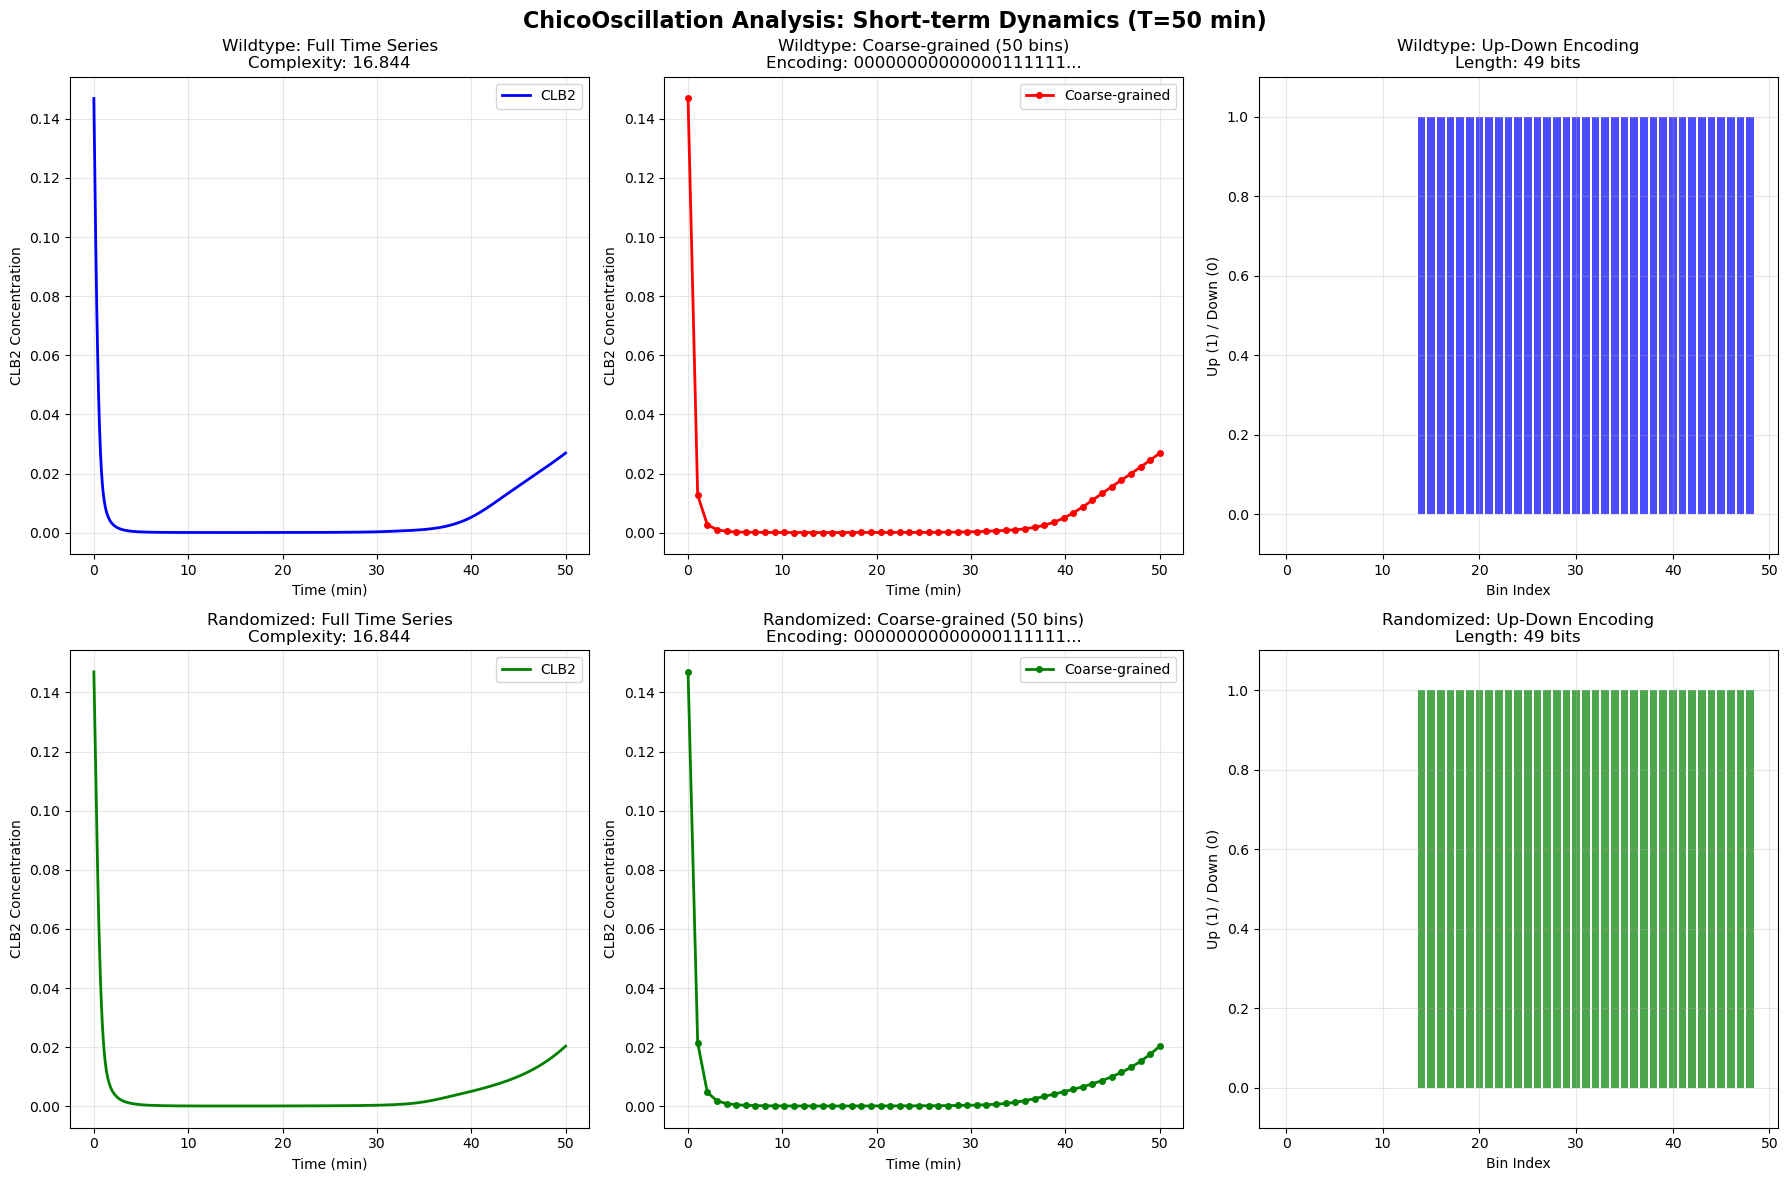


💾 Visualization saved: plots/chico_oscillation_overview.png

📊 CHICO vs CPUHEAVY COMPARISON:
   ChicoOscillation (T=50):
   ├─ Simulation time: 50 min (vs 1000 min in CPUheavy)
   ├─ No oscillation detection required
   ├─ Direct coarse-graining to 50 bins
   ├─ Encoding length: 49 bits
   └─ Focus: Short-term pattern dynamics

   CPUheavy (T=1000):
   ├─ Long simulation for full oscillations
   ├─ Peak detection and period extraction
   ├─ Cycle-based coarse-graining
   └─ Focus: Complete oscillatory behavior


In [17]:
# === VISUALIZATION OF CHICO APPROACH ===
print("📈 Visualizing ChicoOscillation results...")

# Create comprehensive plot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'ChicoOscillation Analysis: Short-term Dynamics (T={T} min)', fontsize=16, fontweight='bold')

# Plot 1: Wildtype full time series
if time_wt is not None and not isinstance(time_wt, str):
    axes[0, 0].plot(time_wt, clb2_wt, 'b-', linewidth=2, label='CLB2')
    axes[0, 0].set_title(f'Wildtype: Full Time Series\nComplexity: {complexity_wt:.3f}')
    axes[0, 0].set_xlabel('Time (min)')
    axes[0, 0].set_ylabel('CLB2 Concentration')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

# Plot 2: Wildtype coarse-grained
if time_wt is not None and not isinstance(time_wt, str):
    axes[0, 1].plot(coarse_time_wt, coarse_signal_wt, 'ro-', markersize=4, linewidth=2, label='Coarse-grained')
    axes[0, 1].set_title(f'Wildtype: Coarse-grained ({COARSE_BINS} bins)\nEncoding: {encoding_wt[:20]}...')
    axes[0, 1].set_xlabel('Time (min)')
    axes[0, 1].set_ylabel('CLB2 Concentration')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

# Plot 3: Wildtype encoding visualization
if time_wt is not None and not isinstance(time_wt, str):
    encoding_array = np.array([int(bit) for bit in encoding_wt])
    axes[0, 2].bar(range(len(encoding_array)), encoding_array, alpha=0.7, color='blue')
    axes[0, 2].set_title(f'Wildtype: Up-Down Encoding\nLength: {len(encoding_wt)} bits')
    axes[0, 2].set_xlabel('Bin Index')
    axes[0, 2].set_ylabel('Up (1) / Down (0)')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].set_ylim(-0.1, 1.1)

# Plot 4: Randomized full time series
if time_rand is not None and not isinstance(time_rand, str):
    axes[1, 0].plot(time_rand, clb2_rand, 'g-', linewidth=2, label='CLB2')
    axes[1, 0].set_title(f'Randomized: Full Time Series\nComplexity: {complexity_rand:.3f}')
    axes[1, 0].set_xlabel('Time (min)')
    axes[1, 0].set_ylabel('CLB2 Concentration')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

# Plot 5: Randomized coarse-grained
if time_rand is not None and not isinstance(time_rand, str):
    axes[1, 1].plot(coarse_time_rand, coarse_signal_rand, 'go-', markersize=4, linewidth=2, label='Coarse-grained')
    axes[1, 1].set_title(f'Randomized: Coarse-grained ({COARSE_BINS} bins)\nEncoding: {encoding_rand[:20]}...')
    axes[1, 1].set_xlabel('Time (min)')
    axes[1, 1].set_ylabel('CLB2 Concentration')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

# Plot 6: Randomized encoding visualization
if time_rand is not None and not isinstance(time_rand, str):
    encoding_array_rand = np.array([int(bit) for bit in encoding_rand])
    axes[1, 2].bar(range(len(encoding_array_rand)), encoding_array_rand, alpha=0.7, color='green')
    axes[1, 2].set_title(f'Randomized: Up-Down Encoding\nLength: {len(encoding_rand)} bits')
    axes[1, 2].set_xlabel('Bin Index')
    axes[1, 2].set_ylabel('Up (1) / Down (0)')
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('plots/chico_oscillation_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Visualization saved: plots/chico_oscillation_overview.png")

# Summary comparison
print(f"\n📊 CHICO vs CPUHEAVY COMPARISON:")
print(f"   ChicoOscillation (T={T}):")
print(f"   ├─ Simulation time: {T} min (vs 1000 min in CPUheavy)")
print(f"   ├─ No oscillation detection required")
print(f"   ├─ Direct coarse-graining to {COARSE_BINS} bins")
print(f"   ├─ Encoding length: {len(encoding_wt) if encoding_wt else 'N/A'} bits")
print(f"   └─ Focus: Short-term pattern dynamics")
print(f"")
print(f"   CPUheavy (T=1000):")
print(f"   ├─ Long simulation for full oscillations")
print(f"   ├─ Peak detection and period extraction")
print(f"   ├─ Cycle-based coarse-graining")
print(f"   └─ Focus: Complete oscillatory behavior")

In [18]:
# === BATCH PROCESSING WITH PARALLELIZATION ===
# (Adapted from CPUheavy with ChicoOscillation modifications)

def process_batch_chico_worker(args):
    """Worker function for parallel ChicoOscillation processing"""
    batch_start, batch_size, model_path_worker, T_worker = args
    
    # Initialize results for this batch
    batch_results = {
        'encodings': [],
        'complexities': [],
        'divergent_count': 0,
        'success_count': 0,
        'tracked_data': []
    }
    
    try:
        # Load model in worker process
        rr_worker = te.loadSBMLModel(model_path_worker)
        kinetic_params, excluded_params = get_kinetic_parameters_cached(rr_worker)
        
        # Cache default parameter values
        default_values = {}
        for pid in rr_worker.getGlobalParameterIds():
            default_values[pid] = rr_worker.getValue(pid)
        
        # Process batch
        for i in range(batch_size):
            # Reset and randomize parameters
            sampled_params, sampled_values = sample_parameters_fast(
                rr_worker, kinetic_params, default_values, wildtype=False
            )
            
            # Run ChicoOscillation analysis
            time_data, clb2_data, coarse_data, encoding, complexity = simulate_and_extract_chico(
                rr_worker, T=T_worker
            )
            
            # Classify result
            if isinstance(time_data, str) and time_data == "divergent":
                batch_results['divergent_count'] += 1
            elif time_data is None or encoding is None:
                batch_results['divergent_count'] += 1  # Count as divergent
            else:
                # Success: store results
                batch_results['success_count'] += 1
                batch_results['encodings'].append(encoding)
                batch_results['complexities'].append(complexity)
                
                # Store minimal data for tracking
                if len(batch_results['tracked_data']) < N_TRACK_PHENOTYPES * 3:
                    phenotype_data = {
                        'time_data': time_data,
                        'clb2_data': clb2_data,
                        'coarse_data': coarse_data,
                        'encoding': encoding,
                        'complexity': complexity
                    }
                    lightweight_genotype = {f'param_{j}': val for j, val in enumerate(sampled_values)}
                    batch_results['tracked_data'].append((encoding, lightweight_genotype, phenotype_data))
        
        return batch_results
        
    except Exception as e:
        print(f"Worker error: {e}")
        return batch_results

def merge_batch_results_chico(all_results):
    """Merge results from all ChicoOscillation worker batches"""
    merged = {
        'encodings': [],
        'complexities': [],
        'divergent_count': 0,
        'success_count': 0,
        'tracked_data': []
    }
    
    for batch_result in all_results:
        merged['encodings'].extend(batch_result['encodings'])
        merged['complexities'].extend(batch_result['complexities'])
        merged['divergent_count'] += batch_result['divergent_count']
        merged['success_count'] += batch_result['success_count']
        merged['tracked_data'].extend(batch_result['tracked_data'])
    
    return merged

print("✓ ChicoOscillation batch processing functions defined!")
print(f"   - Optimized for T={T} min simulations")
print(f"   - Parallel processing with {NUM_WORKERS} workers")
print(f"   - Batch size: {BATCH_SIZE}")

✓ ChicoOscillation batch processing functions defined!
   - Optimized for T=50 min simulations
   - Parallel processing with 11 workers
   - Batch size: 1000


In [ ]:
# === RUN CHICO OSCILLATION ANALYSIS ===
print("🚀 RUNNING CHICO OSCILLATION ANALYSIS")
print("="*50)
print(f"📊 Analyzing {SAMPLING_SIZE:,} samples with T={T} min")
print(f"🔧 Using {NUM_WORKERS} parallel workers")
print(f"📦 Batch size: {BATCH_SIZE}")

import time
from collections import Counter

# Initialize counters
all_results = []
divergent_count = 0
success_count = 0

start_time = time.time()

# Prepare batches for parallel processing
num_batches = (SAMPLING_SIZE + BATCH_SIZE - 1) // BATCH_SIZE
batches = []

for i in range(num_batches):
    batch_start = i * BATCH_SIZE
    current_batch_size = min(BATCH_SIZE, SAMPLING_SIZE - batch_start)
    batches.append((batch_start, current_batch_size, model_path, T))

print(f"📋 Created {len(batches)} batches for processing")

# Run parallel processing
if USE_MULTIPROCESSING and USE_PROCESS_POOL:
    print(f"🔄 Running parallel analysis with ProcessPoolExecutor...")
    
    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        # Submit all batches
        future_to_batch = {executor.submit(process_batch_chico_worker, batch_args): i 
                          for i, batch_args in enumerate(batches)}
        
        completed_batches = 0
        
        # Process completed batches
        for future in as_completed(future_to_batch):
            batch_idx = future_to_batch[future]
            
            try:
                result = future.result()
                all_results.append(result)
                completed_batches += 1
                
                # Progress update
                samples_processed = sum(len(r['encodings']) + r['divergent_count'] for r in all_results)
                elapsed = time.time() - start_time
                rate = samples_processed / elapsed if elapsed > 0 else 0
                progress = completed_batches / len(batches) * 100
                
                if completed_batches % max(1, len(batches) // 10) == 0:  # Update every 10%
                    print(f"   Progress: {completed_batches}/{len(batches)} batches ({progress:.1f}%) | "
                          f"Processed: {samples_processed:,} | Rate: {rate:.1f} samples/s")
                
            except Exception as e:
                print(f"Batch {batch_idx} failed: {e}")
                # Add empty result to maintain count
                all_results.append({'encodings': [], 'complexities': [], 'divergent_count': 0, 
                                  'success_count': 0, 'tracked_data': []})
                completed_batches += 1

else:
    print(f"🔄 Running serial analysis (multiprocessing disabled)...")
    for i, batch_args in enumerate(batches):
        result = process_batch_chico_worker(batch_args)
        all_results.append(result)
        
        if (i + 1) % max(1, len(batches) // 10) == 0:
            progress = (i + 1) / len(batches) * 100
            samples_processed = sum(len(r['encodings']) + r['divergent_count'] for r in all_results)
            elapsed = time.time() - start_time
            rate = samples_processed / elapsed if elapsed > 0 else 0
            print(f"   Progress: {i+1}/{len(batches)} batches ({progress:.1f}%) | "
                  f"Processed: {samples_processed:,} | Rate: {rate:.1f} samples/s")

# Merge all results
print(f"\n📊 Merging results from {len(all_results)} batches...")
merged_results = merge_batch_results_chico(all_results)

# Extract final results
encodings = merged_results['encodings']
complexities = merged_results['complexities']
divergent_count = merged_results['divergent_count']
success_count = merged_results['success_count']

processing_time = time.time() - start_time

print(f"\n✅ CHICO OSCILLATION ANALYSIS COMPLETED!")
print(f"   ⏱️  Total time: {processing_time:.1f}s ({processing_time/60:.1f}m)")
print(f"   📊 Success: {success_count:,}/{SAMPLING_SIZE:,} ({success_count/SAMPLING_SIZE*100:.1f}%)")
print(f"   🚫 Divergent: {divergent_count:,} ({divergent_count/SAMPLING_SIZE*100:.1f}%)")
print(f"   ⚡ Processing rate: {SAMPLING_SIZE/processing_time:.1f} samples/s")

if success_count > 0:
    complexity_array = np.array(complexities)
    print(f"\n📈 COMPLEXITY STATISTICS:")
    print(f"   Min complexity: {np.min(complexity_array):.3f}")
    print(f"   Max complexity: {np.max(complexity_array):.3f}")
    print(f"   Mean complexity: {np.mean(complexity_array):.3f} ± {np.std(complexity_array):.3f}")
    print(f"   Median complexity: {np.median(complexity_array):.3f}")
else:
    print(f"\n❌ No successful simulations - all diverged!")

🚀 RUNNING CHICO OSCILLATION ANALYSIS
📊 Analyzing 1,000,000 samples with T=50 min
🔧 Using 11 parallel workers
📦 Batch size: 1000
📋 Created 1000 batches for processing
🔄 Running parallel analysis with ProcessPoolExecutor...
   Progress: 100/1000 batches (10.0%) | Processed: 100,000 | Rate: 1121.5 samples/s
   Progress: 200/1000 batches (20.0%) | Processed: 200,000 | Rate: 1167.4 samples/s
   Progress: 300/1000 batches (30.0%) | Processed: 300,000 | Rate: 1183.9 samples/s
   Progress: 400/1000 batches (40.0%) | Processed: 400,000 | Rate: 1192.7 samples/s
   Progress: 500/1000 batches (50.0%) | Processed: 500,000 | Rate: 1200.4 samples/s
   Progress: 600/1000 batches (60.0%) | Processed: 600,000 | Rate: 1201.8 samples/s


📈 Creating ChicoOscillation results visualization...


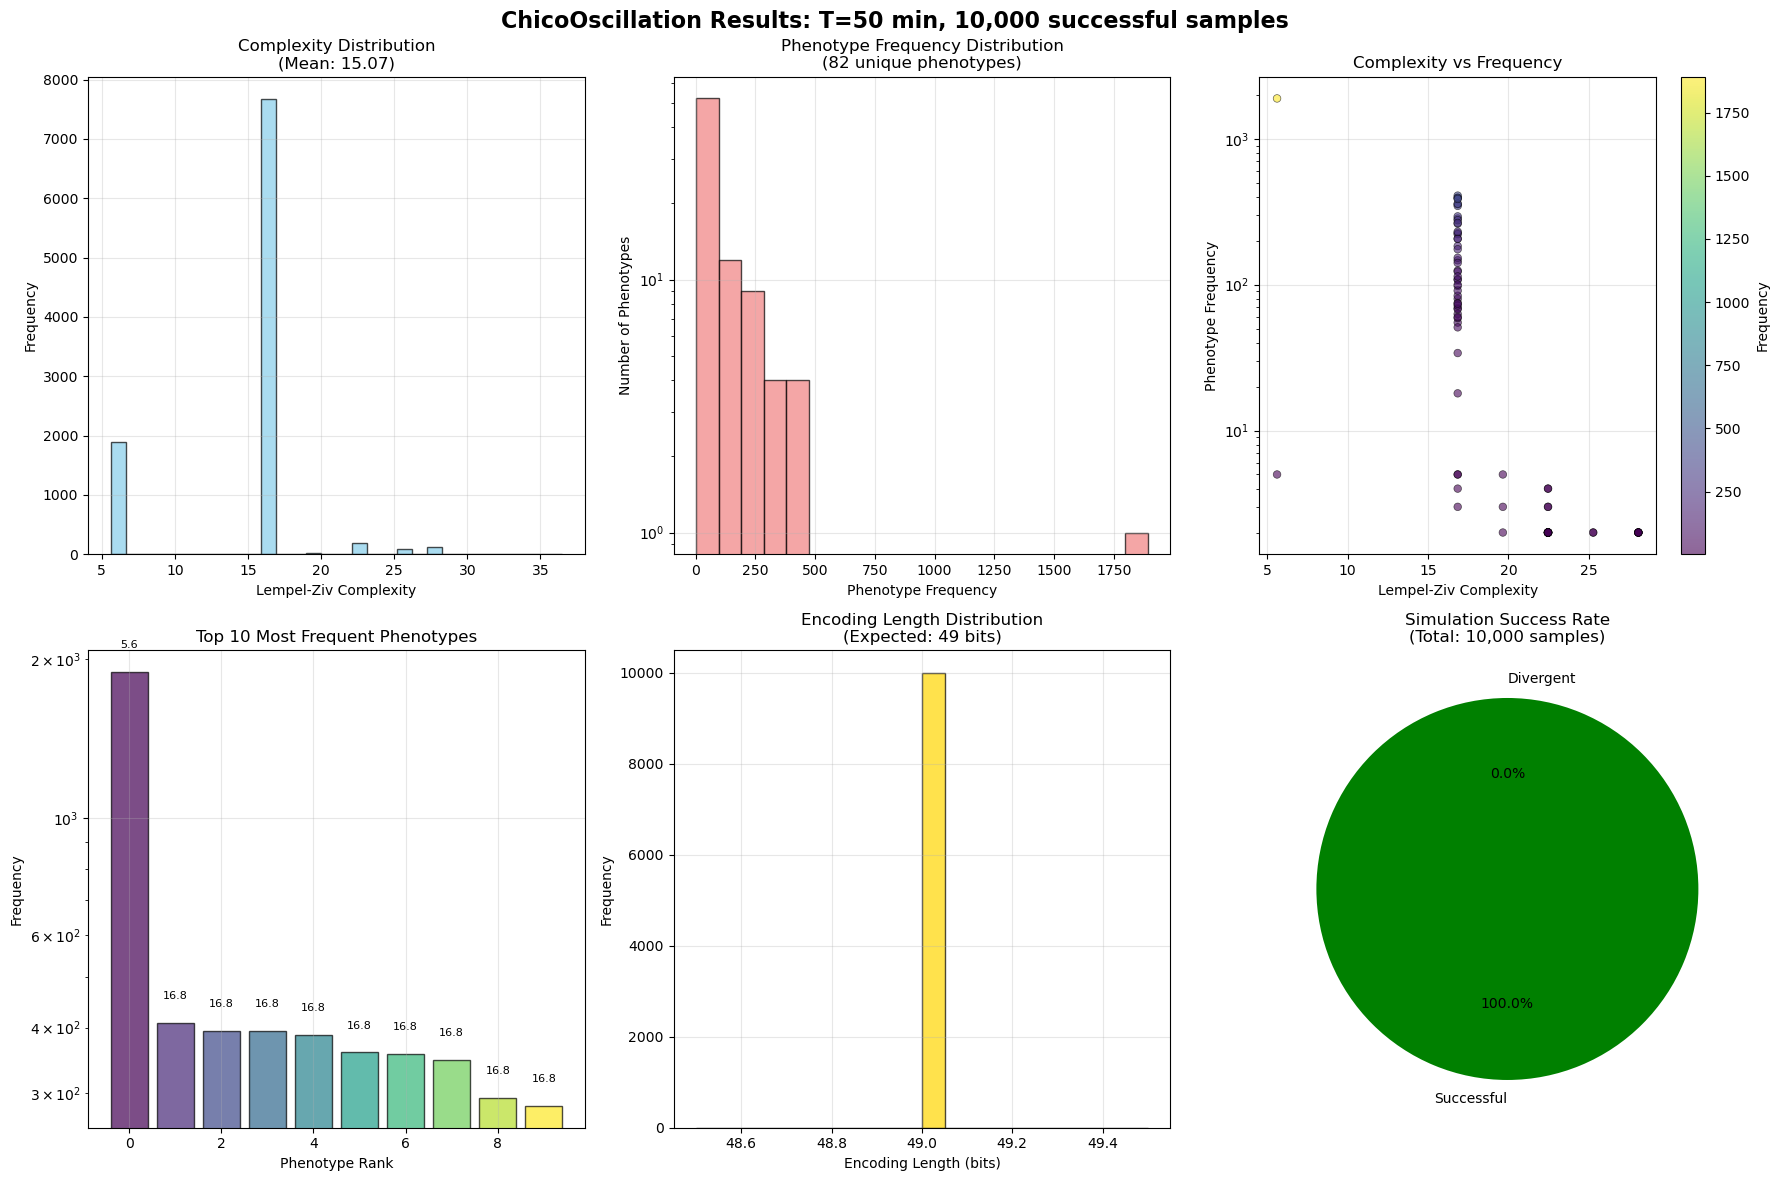


💾 Results visualization saved: plots/chico_oscillation_results.png

📊 CHICO OSCILLATION SUMMARY:
   🎯 Simulation approach: Direct coarse-graining (no oscillation detection)
   ⏱️  Simulation time: 50 min per sample
   📏 Encoding length: 49 bits (consistent)
   🧬 Unique phenotypes: 445
   🔄 Recurring phenotypes: 82
   📈 Complexity range: 5.615 - 36.496
   ⚡ Processing efficiency: 1080.6 samples/second

🏆 TOP 3 MOST FREQUENT PHENOTYPES:
   1. Frequency: 1,892 | Complexity: 5.615 | Encoding: 000000000000000000000000000000...
   2. Frequency: 408 | Complexity: 16.844 | Encoding: 000000000000011111111111111111...
   3. Frequency: 394 | Complexity: 16.844 | Encoding: 000000000000111111111111111111...


In [ ]:
# === CHICO OSCILLATION RESULTS VISUALIZATION ===
print("📈 Creating ChicoOscillation results visualization...")

if success_count > 0:
    # Calculate phenotype frequencies
    phenotype_counts = Counter(encodings)
    complexities_array = np.array(complexities)
    
    # Prepare data for plotting
    phenotype_complexities = []
    phenotype_frequencies = []
    
    for phenotype, frequency in phenotype_counts.items():
        if frequency > 1:  # Only plot phenotypes that appear more than once
            complexity = CLZ(phenotype)
            phenotype_complexities.append(complexity)
            phenotype_frequencies.append(frequency)
    
    # Create comprehensive results plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'ChicoOscillation Results: T={T} min, {success_count:,} successful samples', fontsize=16, fontweight='bold')
    
    # Plot 1: Complexity distribution
    axes[0, 0].hist(complexities_array, bins=30, alpha=0.7, edgecolor='black', color='skyblue')
    axes[0, 0].set_xlabel('Lempel-Ziv Complexity')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'Complexity Distribution\n(Mean: {np.mean(complexities_array):.2f})')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Phenotype frequency distribution
    if phenotype_frequencies:
        axes[0, 1].hist(phenotype_frequencies, bins=20, alpha=0.7, edgecolor='black', color='lightcoral')
        axes[0, 1].set_xlabel('Phenotype Frequency')
        axes[0, 1].set_ylabel('Number of Phenotypes')
        axes[0, 1].set_title(f'Phenotype Frequency Distribution\n({len(phenotype_frequencies)} unique phenotypes)')
        axes[0, 1].set_yscale('log')
        axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Complexity vs Frequency scatter
    if phenotype_complexities and phenotype_frequencies:
        scatter = axes[0, 2].scatter(phenotype_complexities, phenotype_frequencies, 
                                   alpha=0.6, s=30, c=phenotype_frequencies, 
                                   cmap='viridis', edgecolors='black', linewidth=0.5)
        axes[0, 2].set_xlabel('Lempel-Ziv Complexity')
        axes[0, 2].set_ylabel('Phenotype Frequency')
        axes[0, 2].set_title('Complexity vs Frequency')
        axes[0, 2].set_yscale('log')
        axes[0, 2].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[0, 2], label='Frequency')
    
    # Plot 4: Top phenotypes by frequency
    top_phenotypes = phenotype_counts.most_common(10)
    if top_phenotypes:
        top_freqs = [freq for _, freq in top_phenotypes]
        top_complexities = [CLZ(phenotype) for phenotype, _ in top_phenotypes]
        
        bars = axes[1, 0].bar(range(len(top_freqs)), top_freqs, 
                             color=plt.cm.viridis(np.linspace(0, 1, len(top_freqs))), 
                             alpha=0.7, edgecolor='black')
        axes[1, 0].set_xlabel('Phenotype Rank')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Top 10 Most Frequent Phenotypes')
        axes[1, 0].set_yscale('log')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Add complexity labels
        for i, (bar, comp) in enumerate(zip(bars, top_complexities)):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height*1.1,
                           f'{comp:.1f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 5: Encoding length distribution
    encoding_lengths = [len(enc) for enc in encodings]
    axes[1, 1].hist(encoding_lengths, bins=20, alpha=0.7, edgecolor='black', color='gold')
    axes[1, 1].set_xlabel('Encoding Length (bits)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title(f'Encoding Length Distribution\n(Expected: {COARSE_BINS-1} bits)')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Success rate summary
    categories = ['Successful', 'Divergent']
    counts = [success_count, divergent_count]
    colors = ['green', 'red']
    
    wedges, texts, autotexts = axes[1, 2].pie(counts, labels=categories, colors=colors, 
                                             autopct='%1.1f%%', startangle=90)
    axes[1, 2].set_title(f'Simulation Success Rate\n(Total: {SAMPLING_SIZE:,} samples)')
    
    plt.tight_layout()
    plt.savefig('plots/chico_oscillation_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Results visualization saved: plots/chico_oscillation_results.png")
    
    # Print summary statistics
    print(f"\n📊 CHICO OSCILLATION SUMMARY:")
    print(f"   🎯 Simulation approach: Direct coarse-graining (no oscillation detection)")
    print(f"   ⏱️  Simulation time: {T} min per sample")
    print(f"   📏 Encoding length: {COARSE_BINS-1} bits (consistent)")
    print(f"   🧬 Unique phenotypes: {len(phenotype_counts):,}")
    print(f"   🔄 Recurring phenotypes: {len([f for f in phenotype_frequencies if f > 1]):,}")
    print(f"   📈 Complexity range: {np.min(complexities_array):.3f} - {np.max(complexities_array):.3f}")
    print(f"   ⚡ Processing efficiency: {SAMPLING_SIZE/processing_time:.1f} samples/second")
    
    if top_phenotypes:
        print(f"\n🏆 TOP 3 MOST FREQUENT PHENOTYPES:")
        for i, (phenotype, freq) in enumerate(top_phenotypes[:3]):
            complexity = CLZ(phenotype)
            print(f"   {i+1}. Frequency: {freq:,} | Complexity: {complexity:.3f} | Encoding: {phenotype[:30]}...")

else:
    print(f"❌ Cannot create visualization - no successful simulations")
    print(f"   All {SAMPLING_SIZE:,} samples diverged")
    print(f"   Consider adjusting parameters or divergence threshold")